In [1]:
from typing import TypedDict

class State(TypedDict):
    question: str
    research: str
    web_search: str
    memory: str
    final_answer: str

In [2]:
def research_node(state: State):
    print("[병렬1 - research_node] 전문 연구 중...")
    return {"research": f"[연구] {state['question']}에 대한 깊이 있는 분석"}

In [3]:
def web_search_node(state: State):
    print("[병렬2 - web_search_node] 웹 검색 중...")
    return {"web_search": f"[웹] {state['question']} 관련 최신 정보"}

In [4]:
def recall_memory_node(state: State):
    print("[병렬3 - recall_memory_node] 과거 대화 기억 불러오는 중...")
    return {"memory": "이전 대화에서 비슷한 질문이 있었음"}

In [5]:
def combine_node(state: State):
    print("[최종 - combine_node] 모든 결과를 통합")
    combined = (
        f"질문: {state['question']}\n"
        f"- 연구: {state.get('research', '')}\n"
        f"- 웹 검색: {state.get('web_search', '')}\n"
        f"- 메모리: {state.get('memory', '')}\n"
    )
    return {"final_answer": combined}

In [6]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

graph_builder.add_node(research_node)
graph_builder.add_node(web_search_node)
graph_builder.add_node(recall_memory_node)
graph_builder.add_node(combine_node)

In [8]:
graph_builder.add_edge(START, "research_node")
graph_builder.add_edge(START, "web_search_node")
graph_builder.add_edge(START, "recall_memory_node")

graph_builder.add_edge("research_node", "combine_node")
graph_builder.add_edge("web_search_node", "combine_node")
graph_builder.add_edge("recall_memory_node", "combine_node")

graph_builder.add_edge("combine_node", END)

graph = graph_builder.compile()

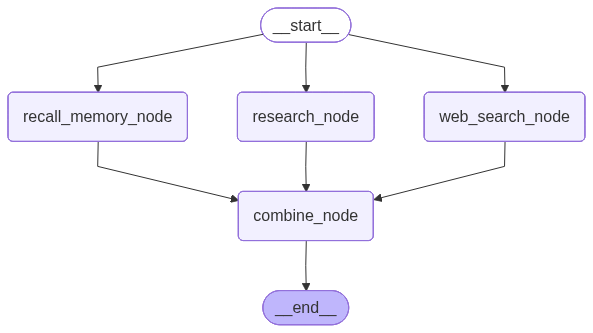

In [9]:
graph

In [13]:
graph.invoke({"question": "LangGraph란?"})

[병렬3 - recall_memory_node] 과거 대화 기억 불러오는 중...
[병렬1 - research_node] 전문 연구 중...
[병렬2 - web_search_node] 웹 검색 중...
[최종 - combine_node] 모든 결과를 통합


{'question': 'LangGraph란?',
 'research': '[연구] LangGraph란?에 대한 깊이 있는 분석',
 'web_search': '[웹] LangGraph란? 관련 최신 정보',
 'memory': '이전 대화에서 비슷한 질문이 있었음',
 'final_answer': '질문: LangGraph란?\n- 연구: [연구] LangGraph란?에 대한 깊이 있는 분석\n- 웹 검색: [웹] LangGraph란? 관련 최신 정보\n- 메모리: 이전 대화에서 비슷한 질문이 있었음\n'}